# AmajLime analysis

In [ ]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Dataframe construction

The data analysed in this notebook was generated from an endpoint fluorescent measurement. The data was parsed from the original .txt file to create the following dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

data_structure = {
 'Number': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 11],
 'Sample': ['Negative', 'Negative', 'Negative', 'T7-1', 'T7-1', 'T7-1', 'T7-2', 'T7-2', 'T7-2', 'T7-3', 'T7-3', 'T7-3', 'T7-4', 'T7-4', 'T7-4', 'T7-5', 'T7-5', 'T7-5', 'T7-6', 'T7-6', 'T7-6', 'T7-7', 'T7-7', 'T7-7', 'T7-8', 'T7-8', 'T7-8', 'T7-9', 'T7-9', 'T7-9', 'T7-10', 'T7-10', 'T7-10'],
 'Fluorescence Units': [6070.0, 6233.0, 6261.0, 4380.0, 6351.0, 2616.0, 6449.0, 6562.0, 6224.0, 19444.0, 20506.0, 18755.0, 7198.0, 6906.0, 6796.0, 45736.0, 43061.0, 47363.0, 27326.0, 31660.0, 30357.0, 13390.0, 12505.0, 11574.0, 442462.0, 442018.0, 427332.0, 1098370.0, 1047753.0, 1026269.0, 1026679.0, 992618.0, 1026745.0]
}


data = pd.DataFrame(data_structure)

#data.head

# Background subtraction 

A new column was added to the dataframe,"blanked", in which the mean fluorescence value of the "Negative" replicates was substracted from the fluorescence values of all samples.


In [2]:

background = data.loc[data["Sample"] == "Negative", "Fluorescence Units"].mean()

data["Blanked"] = data["Fluorescence Units"] - background

data.head

<bound method NDFrame.head of     Number    Sample  Fluorescence Units    Blanked
0        1  Negative              6070.0     -118.0
1        1  Negative              6233.0       45.0
2        1  Negative              6261.0       73.0
3        2      T7-1              4380.0    -1808.0
4        2      T7-1              6351.0      163.0
5        2      T7-1              2616.0    -3572.0
6        3      T7-2              6449.0      261.0
7        3      T7-2              6562.0      374.0
8        3      T7-2              6224.0       36.0
9        4      T7-3             19444.0    13256.0
10       4      T7-3             20506.0    14318.0
11       4      T7-3             18755.0    12567.0
12       5      T7-4              7198.0     1010.0
13       5      T7-4              6906.0      718.0
14       5      T7-4              6796.0      608.0
15       6      T7-5             45736.0    39548.0
16       6      T7-5             43061.0    36873.0
17       6      T7-5             4

# Plotting: AmajLime summary plot 

The plot order and color map is first defined to categorise the reporters into color coded low, medium, and high expression level groups. This enables easier visualisation of the dataset. The endpoint background substracted fluorescence units are then plotted for each promoter. A scatter plot is used to illustrate the overall spread of the data.

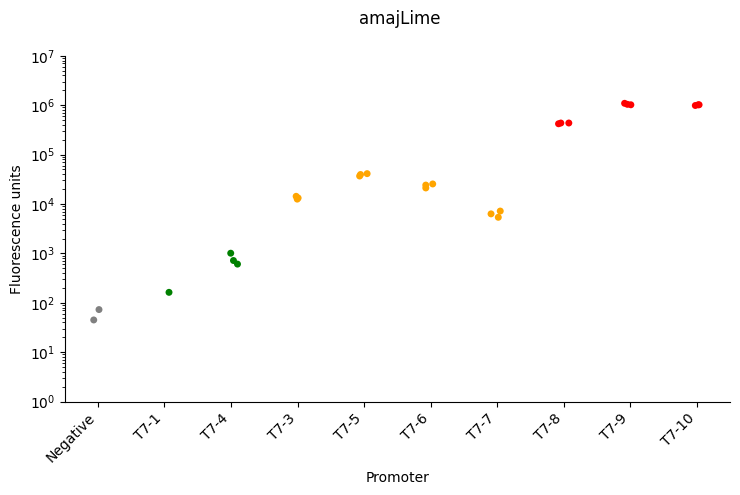

In [4]:
#| label: amajLime-final-summary

plot_order = [
    'Negative',
    'T7-1',
    'T7-4',
    'T7-3',
    'T7-5',
    'T7-6',
    'T7-7',
   'T7-8',
   'T7-9',
    'T7-10'
]

color_map = {
    'Negative': 'grey', 
    'T7-1': 'green',
    'T7-4': 'green',
    'T7-3': 'orange',
    'T7-5': 'orange',
    'T7-6': 'orange',
    'T7-7': 'orange',
    'T7-8': 'red',
    'T7-9': 'red',
    'T7-10': 'red'
}

amajLime_plot=sns.catplot(
    data=data, 
    x='Sample',            
    y='Blanked',
    order=plot_order,
    palette=color_map,
    kind='strip',          
    height=5,              
    aspect=1.5             
)

amajLime_plot.fig.suptitle('amajLime', x=0.54) 
amajLime_plot.set_axis_labels('Promoter', 'Fluorescence units') 
amajLime_plot.set_xticklabels(rotation=45, ha='right') 
amajLime_plot.set(yscale="log", ylim=(1, 10000000))

plt.tight_layout()
amajLime_plot.savefig('Summary_data_amajLime.png', dpi=600)
